### Previous Exploratory Data Analysis
#### The file transform.py has been developed with the definitive workflow of this notebook

In [1]:
# Importing modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
from datetime import datetime, timedelta

In [2]:
# Setting up the path to include the parent directory
sys.path.append(str(Path.cwd().parent))
from backend.config.settings import PATHS

In [3]:
water_path = PATHS['raw_data'] / 'water.csv'
water_pd = pd.read_csv(water_path)
water_pd.head()

,DATE,CURRENT_WATER,ID
0,04/09/12 00:00,56.0,18
1,23/10/12 00:00,50.0,18
2,27/11/12 00:00,55.0,18
3,22/01/91 00:00,53.0,18
4,21/05/91 00:00,52.0,18


In [202]:
reservoirs_path = PATHS['raw_data'] / 'reservoirs.csv'
reservoirs_pd = pd.read_csv(reservoirs_path)
reservoirs_pd.head()

,ID,SCOPE_NAME,RESERVOIR_NAME,TOTAL_WATER,ELECTRIC_FLAG
0,1,GUADALQUIVIR,"BREÑA, LA",103.0,0
1,3,GUADALQUIVIR,"FERNANDINA, LA",247.0,0
2,5,GUADALQUIVIR,PUEBLA DE CAZALLA,87.0,0
3,6,GUADALQUIVIR,PEDRO MARÍN,19.0,0
4,9,CUENCA MEDITERRÁNEA ANDALUZA,"VIÑUELA, LA",170.0,0


In [5]:
detailed_path = PATHS['raw_data'] / 'UTF8list-3.tsv'
detailed_reservoirs_pd = pd.read_csv(detailed_path, sep='\t')
detailed_reservoirs_pd.head()

,CODE,NAME,RESERVOIR,X,Y,BASIN,RIVERBED,GOOGLE,OPENSTREETMAP,WIKIDATA,PROVINCE,AUTONOMOUS_COMMUNITY,TYPE,CREST_ELEVATION,DAM_HEIGHT,REPORT
0,9250031,SALLENTE,SALLENTE,"42,5003709690001","0,991459934000034",EBRO,BARRANC DE LA LORA,NaN,NaN,NaN,Lleida,Cataluña,Presa de materiales sueltos de pantalla asfáltica,1770,89,https://sig.mapama.gob.es/WebServices/clientew...
1,3450047,CAZALEGAS,Cazalegas Dam,"40,01298709","-4,70624804799996",TAJO,RÍO ALBERCHE,https://www.google.com/search?kgmid=/g/11dfr4j268,NaN,https://www.wikidata.org/wiki/Q30278314,Toledo,Castilla - La Mancha,Presa de materiales sueltos de pantalla de hor...,NaN,NaN,https://sig.mapama.gob.es/WebServices/clientew...
2,9250014,LAGO NEGRO,LAGO NEGRO,"42,5422861970001","1,04058219400002",EBRO,NaN,NaN,NaN,NaN,Lleida,Cataluña,Presa de materiales sueltos zonificada o de nú...,2340,11,https://sig.mapama.gob.es/WebServices/clientew...
3,9500034,"TORCAS, LAS",Las Trocas reservoir,"41,294686266","-1,08744698599997",EBRO,RÍO HUERVA,NaN,NaN,https://www.wikidata.org/wiki/Q23991169,Zaragoza,Aragón,Presa de fábrica de gravedad (hormigón vibrado),"624,799999999999","39,45",https://sig.mapama.gob.es/WebServices/clientew...
4,3190006,"BUJEDA, LA","BUJEDA, LA","40,244500658","-2,83518801499997",TAJO,SIN NOMBRE,NaN,NaN,NaN,Guadalajara,Castilla - La Mancha,Presa de materiales sueltos homogénea,"905,5","39,5",https://sig.mapama.gob.es/WebServices/clientew...


In [6]:
# First we will make sure that every data is in the correct format
water_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 683447 entries, 0 to 683446
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   DATE           683447 non-null  object 
 1   CURRENT_WATER  683445 non-null  float64
 2   ID             683447 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 15.6+ MB


## WATER DATAFRAME

### Missing Values

In [12]:
# Now we will check if there are any missing values in the dataFrame
water_pd.isna().sum()

DATE             0
CURRENT_WATER    2
ID               0
dtype: int64

In [14]:
# As there are only two rows with missing values, we can drop them
water_pd = water_pd.dropna()
water_pd.isna().sum()

DATE             0
CURRENT_WATER    0
ID               0
dtype: int64

### Date column to datetime

In [51]:
# The exact time is irrelevant
water_pd_split = water_pd['DATE'].str.rsplit(pat='/', n=1, expand=True)
print(f"We split the dataframe conveniently: \n{water_pd_split}")
year_counts = water_pd_split[1].str.split(' ').str[0].value_counts().sort_index()

We split the dataframe conveniently: 
            0         1
0       04/09  12 00:00
1       23/10  12 00:00
2       27/11  12 00:00
3       22/01  91 00:00
4       21/05  91 00:00
...       ...       ...
683442  24/05  22 00:00
683443  21/06  22 00:00
683444  06/09  22 00:00
683445  27/09  22 00:00
683446  17/01  23 00:00

[683445 rows x 2 columns]


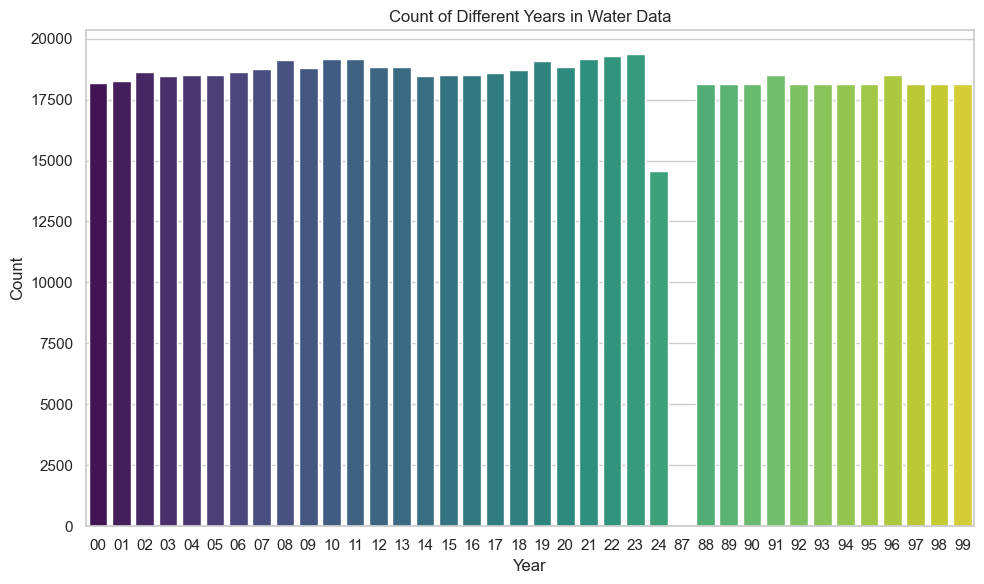

In [53]:
# Seaborn barplot to visualize the count of different years
plt.figure(figsize=(10, 6))
sns.barplot(x=year_counts.index, y=year_counts.values, hue=year_counts.index, palette='viridis', legend=False)
plt.title('Count of Different Years in Water Data')
plt.xlabel('Year')
plt.ylabel('Count')
plt.tight_layout()

In [63]:
two_digit_years = water_pd_split[1].str.split(' ').str[0].astype(int)
print(f"Two digit years: \n{two_digit_years}")

complete_years = two_digit_years.apply(lambda x: x + 1900 if x >= 85 else x + 2000)
print(f"Full years: \n{complete_years}")

Two digit years: 
0         12
1         12
2         12
3         91
4         91
          ..
683442    22
683443    22
683444    22
683445    22
683446    23
Name: 1, Length: 683445, dtype: int64
Full years: 
0         2012
1         2012
2         2012
3         1991
4         1991
          ... 
683442    2022
683443    2022
683444    2022
683445    2022
683446    2023
Name: 1, Length: 683445, dtype: int64


In [76]:
definite_date_column = water_pd_split[0] + '/' + complete_years.astype(str)
print(f"Definite date column: \n {definite_date_column}")

water_pd['DATE'] = pd.to_datetime(definite_date_column, format='%d/%m/%Y')

Definite date column: 
 0         04/09/2012
1         23/10/2012
2         27/11/2012
3         22/01/1991
4         21/05/1991
             ...    
683442    24/05/2022
683443    21/06/2022
683444    06/09/2022
683445    27/09/2022
683446    17/01/2023
Length: 683445, dtype: object


### Visualize how much data we have for one reservoir

In [100]:
id1 = water_pd[water_pd['ID'] == 1].drop(columns=['ID'])
print(id1.info())
id1.set_index('DATE', inplace=True)

<class 'pandas.core.frame.DataFrame'>
Index: 1147 entries, 5467 to 658620
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   DATE           1147 non-null   datetime64[ns]
 1   CURRENT_WATER  1147 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 26.9 KB
None


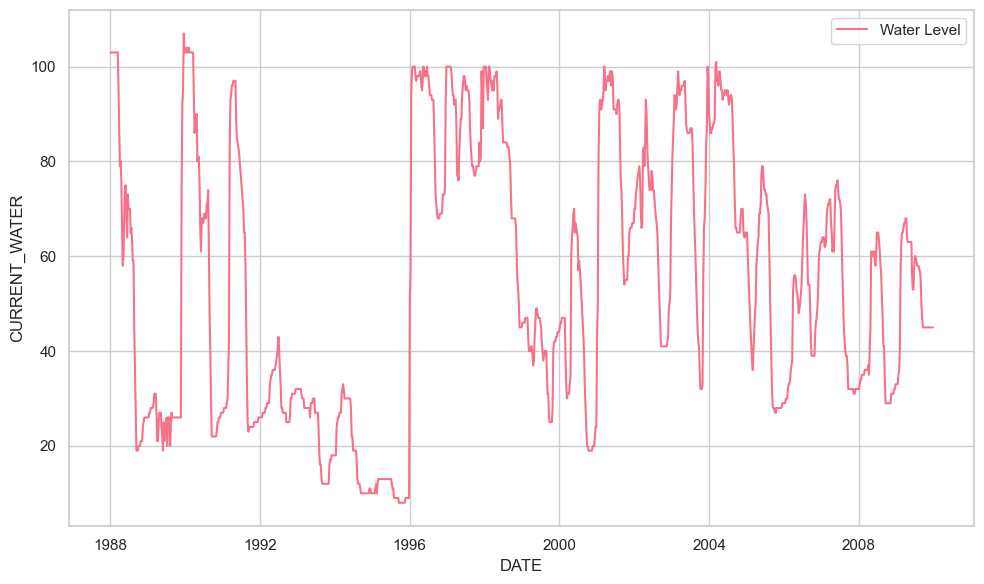

In [101]:
plt.figure(figsize=(10,6))
sns.lineplot(data=id1, x=id1.index, y='CURRENT_WATER', label='Water Level')
plt.tight_layout()

### Renaming columns

In [176]:
columns_dict = {'DATE': 'date', 'CURRENT_WATER': 'storage', 'ID': 'id'}
water_pd.rename(columns=columns_dict, inplace=True)

In [177]:
water_pd.head()

,date,storage,id
0,2012-09-04,56.0,18
1,2012-10-23,50.0,18
2,2012-11-27,55.0,18
3,1991-01-22,53.0,18
4,1991-05-21,52.0,18


### Converting storage to Integer

In [189]:
# Let's ensure that every float is actually an int
print(f"Number of rows: {len(water_pd)}")
print(f"Number of int at storage: {len(water_pd[water_pd['storage'] == water_pd['storage'].apply(int)])}")

Number of rows: 683445
Number of int at storage: 683445


In [190]:
water_pd['storage'] = water_pd['storage'].astype(int)

# RESERVOIRS DATAFRAME

#### The detailed_reservoirs dataframe is the interesting one in terms of complexity

In [102]:
reservoirs_pd.head()

,ID,SCOPE_NAME,RESERVOIR_NAME,TOTAL_WATER,ELECTRIC_FLAG
0,1,GUADALQUIVIR,"BREÑA, LA",103.0,0
1,3,GUADALQUIVIR,"FERNANDINA, LA",247.0,0
2,5,GUADALQUIVIR,PUEBLA DE CAZALLA,87.0,0
3,6,GUADALQUIVIR,PEDRO MARÍN,19.0,0
4,9,CUENCA MEDITERRÁNEA ANDALUZA,"VIÑUELA, LA",170.0,0


In [118]:
reservoirs_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 401 entries, 0 to 400
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              401 non-null    int64  
 1   SCOPE_NAME      401 non-null    object 
 2   RESERVOIR_NAME  401 non-null    object 
 3   TOTAL_WATER     400 non-null    float64
 4   ELECTRIC_FLAG   401 non-null    int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 15.8+ KB


### Missing values

In [203]:
reservoirs_pd.isna().sum()

ID                0
SCOPE_NAME        0
RESERVOIR_NAME    0
TOTAL_WATER       1
ELECTRIC_FLAG     0
dtype: int64

In [204]:
# As it's the capacity of the reservoir, we will fill it with the maximum registered value
id_to_current_water = water_pd.groupby('id')['storage'].max() # Creates a series with 'ID' as index
mask = reservoirs_pd['TOTAL_WATER'].isna()
reservoirs_pd.loc[mask, 'TOTAL_WATER'] = reservoirs_pd.loc[mask, 'ID'].map(id_to_current_water) # Replacing missing values efficiently

### Renaming columns

In [205]:
columns_dict = {'ID': 'id', 'SCOPE_NAME': 'scope', 'RESERVOIR_NAME': 'name', 'TOTAL_WATER':'capacity', 'ELECTRIC_FLAG': 'electric_flag'}
reservoirs_pd.rename(columns=columns_dict, inplace=True)

### Converting capacity to Integer

In [206]:
# Let's ensure that every float is actually an int
print(f"Number of rows: {len(reservoirs_pd)}")
print(f"Number of int at capacity: {len(reservoirs_pd[reservoirs_pd['capacity'] == reservoirs_pd['capacity'].apply(int)])}")

Number of rows: 401
Number of int at capacity: 401


In [207]:
reservoirs_pd['capacity'] = reservoirs_pd['capacity'].astype(int)

### Text Cleaning

In [216]:
reservoirs_pd.head()

,id,scope,name,capacity,electric_flag
0,1,GUADALQUIVIR,"BREÑA, LA",103,0
1,3,GUADALQUIVIR,"FERNANDINA, LA",247,0
2,5,GUADALQUIVIR,PUEBLA DE CAZALLA,87,0
3,6,GUADALQUIVIR,PEDRO MARÍN,19,0
4,9,CUENCA MEDITERRÁNEA ANDALUZA,"VIÑUELA, LA",170,0


In [217]:
replacement_mapping = {'á': 'a', 'é': 'e', 'í': 'i', 'ó': 'o', 'ú': 'u', 'ñ': 'n', 'ü': 'u', 'ç': 'c', ',': ' '}
articles = [' el ', ' la ', ' los ', ' las ', ' un ', ' una ', ' unos ', ' unas ']
articles_mapping = {article: ' ' for article in articles}

def clean_string_series(series):
    """
    Cleans a pandas Series by lowercasing, replacing accents, removing articles, and stripping whitespace.
    """
    # Lowercasing
    series = series.str.lower()
    
    # Replacing accents and special characters
    series = series.replace(replacement_mapping, regex=True)
    
    # Adding spaces around the strings and articles to avoid removing parts of words when removing articles
    series = ' ' + series + ' '
    
    # Removing articles
    series = series.replace(articles_mapping, regex=True)
    
    # Stripping whitespace
    series = series.str.strip()
    
    return series

reservoirs_pd['name'] = clean_string_series(reservoirs_pd['name'])
reservoirs_pd['scope'] = clean_string_series(reservoirs_pd['scope'])

In [218]:
reservoirs_pd.head()

,id,scope,name,capacity,electric_flag
0,1,guadalquivir,brena,103,0
1,3,guadalquivir,fernandina,247,0
2,5,guadalquivir,puebla de cazalla,87,0
3,6,guadalquivir,pedro marin,19,0
4,9,cuenca mediterranea andaluza,vinuela,170,0


In [ ]:
## Clean and join detailed_reservoirs_pd['NAME'] with reservoirs_pd['name']
replacement_mapping = {'á': 'a', 'é': 'e', 'í': 'i', 'ó': 'o', 'ú': 'u', 'ñ': 'n', 'ü': 'u', 'ç': 'c', ',': ' ', '-': ' ', '/': ' ', '.': ' '}
articles = [' el ', ' la ', ' los ', ' las ', ' un ', ' una ', ' unos ', ' unas ']
articles_mapping = {article: ' ' for article in articles}

def clean_string_series(series):
    series = series.str.lower()
    series = series.replace(replacement_mapping, regex=True)
    series = series.str.replace(r'\s+', ' ', regex=True)
    series = ' ' + series + ' '
    series = series.replace(articles_mapping, regex=True)
    series = series.str.replace(r'\s+', ' ', regex=True)
    series = series.str.strip()
    return series

# Clean columns
reservoirs_pd['name_clean'] = clean_string_series(reservoirs_pd['name'])
detailed_reservoirs_pd['NAME_clean'] = clean_string_series(detailed_reservoirs_pd['NAME'])

# Full outer join on name_clean <-> NAME_clean
merged = pd.merge(reservoirs_pd, detailed_reservoirs_pd, left_on='name_clean', right_on='NAME_clean', how='outer', indicator=True)

# Filter to only paired rows (matched in both DataFrames)
paired = merged[merged['_merge'] == 'both']

print(f"Total merged rows: {len(merged)}")
print(f"Paired rows: {len(paired)}")
print(paired.head())

In [219]:
reservoirs_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 401 entries, 0 to 400
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             401 non-null    int64 
 1   scope          401 non-null    object
 2   name           401 non-null    object
 3   capacity       401 non-null    int64 
 4   electric_flag  401 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 15.8+ KB


In [220]:
detailed_reservoirs_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   CODE                  367 non-null    int64 
 1   NAME                  367 non-null    object
 2   RESERVOIR             367 non-null    object
 3   X                     367 non-null    object
 4   Y                     367 non-null    object
 5   BASIN                 367 non-null    object
 6   RIVERBED              359 non-null    object
 7   GOOGLE                115 non-null    object
 8   OPENSTREETMAP         36 non-null     object
 9   WIKIDATA              187 non-null    object
 10  PROVINCE              367 non-null    object
 11  AUTONOMOUS_COMMUNITY  367 non-null    object
 12  TYPE                  367 non-null    object
 13  CREST_ELEVATION       184 non-null    object
 14  DAM_HEIGHT            184 non-null    object
 15  REPORT                367 non-null    ob